In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")

from Autograd import Tensor
from Loss import cross_entropy_loss
from Model import Linear,Layernorm,Embedding,Module,MultiHeadAttention,FFN
from Transformer import Transformer
from Optimiser import Adam
from Training import training
from Tiny_Shakespeare_Data_Prep import data_read,generate_dataset
from Model_saving import save_model,load_model

In [2]:
block_size=64
embedding_dim=16
no_heads=2
hidden_dim=64
no_blocks=3

epochs=100
batch_size=64

In [3]:
vocab_size,encode_dict,decode_dict,tokens=data_read()

n=int(len(tokens)*0.7)

train_in,train_out=generate_dataset(tokens[:n],block_size)
test_in,test_out=generate_dataset(tokens[n:],block_size)

In [4]:
model=Transformer(embedding_dim=embedding_dim,no_heads=no_heads,vocab_size=vocab_size,block_size=block_size,hidden_dim=hidden_dim,no_blocks=no_blocks)
loss_fn=cross_entropy_loss
optimiser=Adam(params=model.parameters(),lr=0.001,beta1=0.9,beta2=0.999,epsilon=1e-9)

In [ ]:
loss=training(train_in,model,train_out,loss_fn,epochs,optimiser,batch_size)

0.09025544132824022


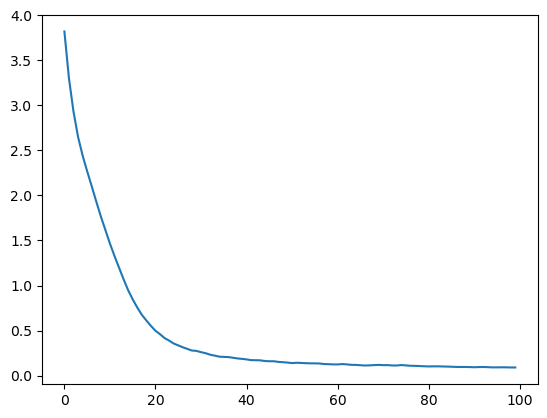

In [ ]:
plt.plot(loss)
print(loss[-1])

In [ ]:
save_model(model,"transformer_weights.npy")

NameError: name 'save_model' is not defined

In [ ]:
load_model(model,"transformer_weights.npy")